<a href="https://colab.research.google.com/github/mpintoponce/python_utec/blob/main/Modulo03%3AVisualizacion_de_Datos/Python_Tarea_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![picture](https://drive.google.com/uc?export=view&id=1KaUW3_JAieeY7WVNfoRiTSr2JsaeAcXi)

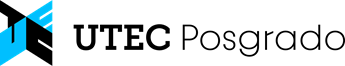


# **Módulo 3** - Sesión 5:  **Viualización de Datos Cuantitativos**
## Profesor: Germain Garcia Zanabria

### Indicaciones

Completa las secciones de código en las que se indique `### Completar`. Siga las instrucciones y proporcione la implementación adecuada en cada caso. Si necesitas ayuda o tienes alguna pregunta, no dudes en levantar la mano para que pueda asistirte.

**Nota:**
No olvides completar con tu análisis en las secciones: `La interpretación de tu gráfico anterior`.

## **Assignment:** Análisis Visual

El objetivo de este assignment es prácticar las técnicas de análisis exploratorio de datos para análisis univariado.

### **Paso 0:** Cargar librerías y seleccionar el conjunto de datos que se utilizará para este assignment.

In [4]:
#Importar Librerias
import pandas as pd
import seaborn as sns
import random

La función `cargarDatos()` escogerá al azar el conjunto de datos (dataset) con el que trabajarás en este assignment. Además la función ya te devuelve el dataset cargado en la variable `df`

In [6]:
def cargarDatos():
  datasetList = ["taxis", "flights", "planets"]
  rand_idx = random.randrange(len(datasetList))
  random_dataset = datasetList[rand_idx]
  print("El dataset que utilizarás es: ", random_dataset)
  df = sns.load_dataset(random_dataset)
  return df

In [8]:
#Asigna el dataset al azar y carga el dataset
df= cargarDatos()
df.head()

El dataset que utilizarás es:  taxis


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


### **Paso 1:** Descubre/Explora el conjunto de datos

In [30]:
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [9]:
#Resumen del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

### **Ejercicio 1:** Método gráfico de un dato categórico ✋

Analiza de manera gráfica un dato categórico de tu dataset.

In [10]:
#Tu código aquí
print('La cantidad de pagos que realizan los clientes por metodo de pagos es:')
df.payment.value_counts()

La cantidad de pagos que realizan los clientes por metodo de pagos es:


,count
payment,
credit card,4577
cash,1812


In [11]:
df.payment.value_counts(normalize=True)

,proportion
payment,
credit card,0.716388
cash,0.283612


/tmp/ipython-input-12-139540071.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="payment", data=df, palette= "pastel")


<Axes: xlabel='count', ylabel='payment'>

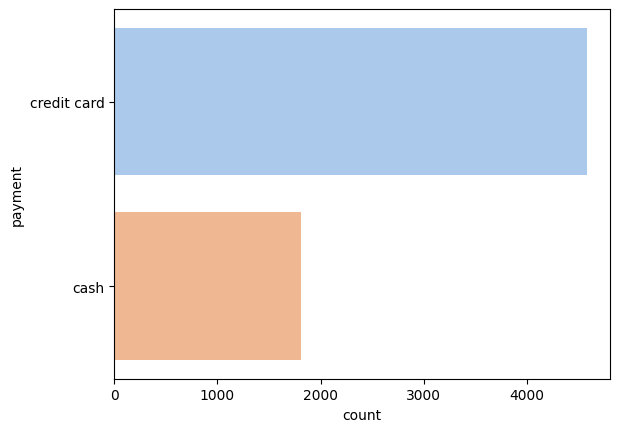

In [12]:
sns.countplot(y="payment", data=df, palette= "pastel")

**Interpretación**

Se observa que hay una mayor cantidad de clientes que pagan en con tarjeta de crédito (71.6%) a comparación de los que pagan en efectivo (28.4%).

### **Ejercicio 2:** Método gráfico de un dato cuantitativo ✋

Analiza de manera gráfica un dato cuantitativo de tu dataset.

<Axes: xlabel='distance', ylabel='Count'>

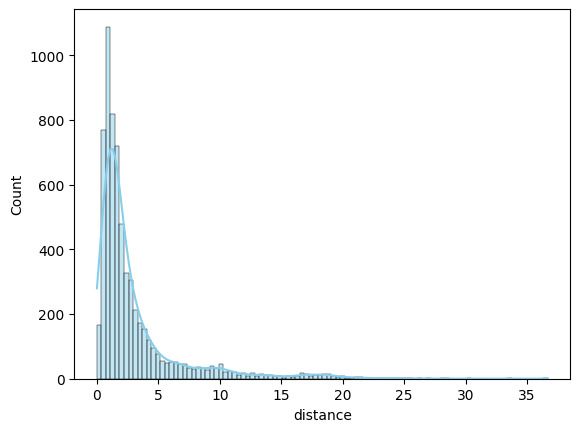

In [18]:
#Tu código aquí
sns.histplot(data=df, x= 'distance', legend= False, kde= True, color= 'Skyblue', bins = 100)

<Axes: ylabel='distance'>

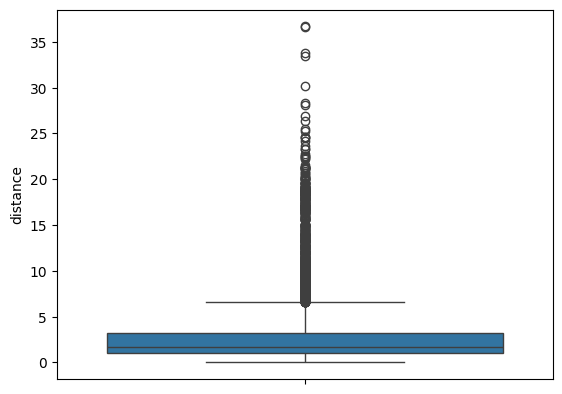

In [19]:
sns.boxplot(data=df, y='distance')

In [37]:
df_filter = df[df['distance'] <= 5]
print(df.shape)
print(df_filter.shape)

(6433, 14)
(5473, 14)


<Axes: ylabel='distance'>

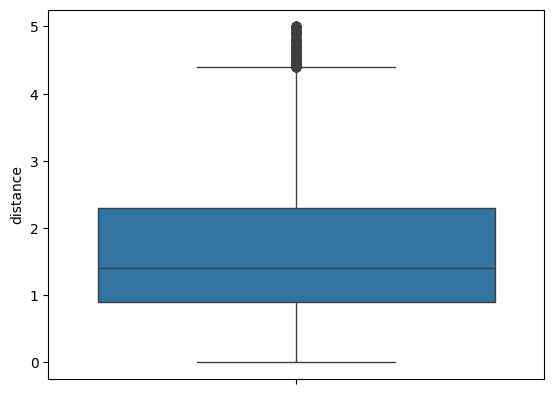

In [38]:
sns.boxplot(data=df_filter, y='distance')

In [41]:
df_filter.distance.describe()

,distance
count,5473.000000
mean,1.707608
std,1.093587
min,0.000000
25%,0.900000
50%,1.400000
75%,2.300000
max,5.000000


<Axes: xlabel='distance', ylabel='Count'>

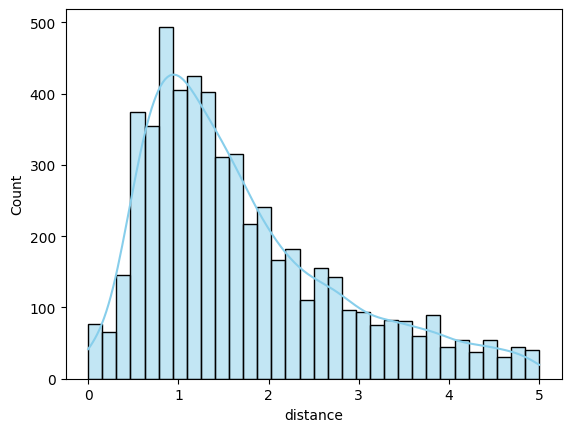

In [39]:
sns.histplot(data=df_filter, x= 'distance', legend= False, kde= True, color= 'Skyblue')

**Variable:** Distancia

**Interpretación:**

La variable cuantitativa 'distance' muestra un histograma con un gran offset, por lo que se realiza un filtro para los valores menor igual a 5.

La media de la variable distance, luego de la limpieza arroja un valor de 1.70, con una desviación estandar de 1.09, lo que significa que la mayor cantidad de datos de distancia se encuentran entre 0.61 y 2.79.


### **Ejercicio 3**: Método gráfico multivariado para datos cuantitativos ✋


In [ ]:
#Tu código aquí


**La interpretación de tu gráfico anterior:** ------
